# Compare pool metrics
Load all metrics parquets from `artifacts/` and compare MAE, RMSE, MAPE across models (baseline, lstm, xgboost, lightgbm, ridge, xgboost_lgb_feats, tcn, xgb_tcn_stack_logreturn, stack_simple_avg, chronos_returns, chronos_price).

In [5]:
from pathlib import Path
import pandas as pd

ARTIFACTS_DIR = Path.cwd() / "artifacts"

files = {
    "baseline": "metrics_baseline_pool.parquet",
    "lstm": "metrics_lstm_pool.parquet",
    "xgboost": "metrics_xgboost_pool.parquet",
    "lightgbm": "metrics_lightgbm_pool.parquet",
    "ridge": "metrics_ridge_pool.parquet",
    "ridge_core": "metrics_ridge_core_pool.parquet",
    "xgboost_lgb_feats": "metrics_xgboost_lgb_feats_pool.parquet",
    "tcn": "metrics_tcn_pool.parquet",
    "xgb_tcn_stack_logreturn": "metrics_xgb_tcn_stack_logreturn_pool.parquet",
    "stack_simple_avg": "metrics_stack_simple_avg_pool.parquet",
    "stack_simple_avg_logreturn": "metrics_stack_simple_avg_logret_pool.parquet",
    "stack_ridge_meta_logreturn": "metrics_stack_ridge_meta_logreturn_pool.parquet",
    "chronos_returns": "metrics_chronos_pool.parquet",
    "chronos_price": "metrics_chronos_pool_price.parquet",
    "xgb_lstm_logreturn":"metrics_xgb_lstm_stack_logreturn_pool.parquet"
}
dfs = []
for name, f in files.items():
    p = ARTIFACTS_DIR / f
    if p.exists():
        df = pd.read_parquet(p).copy()
        df["model"] = name
        dfs.append(df)
    else:
        print(f"Missing: {p}")

if not dfs:
    raise SystemExit("No metrics files found. Run 01–04 pool notebooks first.")
all_metrics = pd.concat(dfs, ignore_index=True)
print("Overall :")
overall = all_metrics[all_metrics["symbol"] == "overall"].sort_values('MAE')
overall

Overall :


,model,symbol,MAE,RMSE,MAPE_%
153,chronos_price,overall,6.341592,8.144852,2.430080
109,stack_simple_avg,overall,6.383610,8.413815,2.436202
120,stack_simple_avg_logreturn,overall,6.402790,8.381850,2.450514
98,xgb_tcn_stack_logreturn,overall,6.412781,8.379771,2.440508
43,lightgbm,overall,6.424309,8.417681,2.444576
131,stack_ridge_meta_logreturn,overall,6.424712,8.410081,2.442460
164,xgb_lstm_logreturn,overall,6.431085,8.399380,2.446703
32,xgboost,overall,6.436510,8.444626,2.444875
142,chronos_returns,overall,6.455411,8.505310,2.454920
65,ridge_core,overall,6.458566,8.451896,2.456347


In [6]:
# Pivot: chronos_price and stack models only — rows = symbol, columns = model, values = MAE / RMSE / MAPE_%
chronos_and_stack = ["chronos_price", "stack_simple_avg", "xgb_tcn_stack_logreturn", "xgb_lstm_logreturn"]
sub = all_metrics[all_metrics["model"].isin(chronos_and_stack)]
for metric in ["MAE", "RMSE", "MAPE_%"]:
    if metric not in sub.columns:
        continue
    pt = sub.pivot_table(index="symbol", columns="model", values=metric)
    print(f"\n--- {metric} (chronos_price + stack) ---")
    print(pt.to_string())
    print()


--- MAE (chronos_price + stack) ---
model    chronos_price  stack_simple_avg  xgb_lstm_logreturn  xgb_tcn_stack_logreturn
symbol                                                                               
AAPL          6.681341          7.759302            6.830115                 6.842214
AMZN          8.823025          8.251977            8.870453                 8.862683
GOOGL         7.926942          8.282412            8.132274                 8.138015
JNJ           4.587719          3.848870            3.943175                 3.955116
JPM           7.432135          7.438598            7.363375                 7.341612
MSFT         10.396342         10.277573           11.168313                11.111099
NVDA          4.508031          4.179048            4.273269                 4.252050
SPY           6.242495          6.785315            6.710045                 6.641219
WMT           2.329413          2.754711            2.504091                 2.490093
XOM           4.4

In [7]:
# Pivot: rows = symbol (or overall), columns = model, values = MAE / RMSE / MAPE_%
for metric in ["MAE", "RMSE", "MAPE_%"]:
    if metric not in all_metrics.columns:
        continue
    pt = all_metrics.pivot_table(index="symbol", columns="model", values=metric)
    print(f"\n--- {metric} ---")
    print(pt.to_string())
    print()
# Print only rows where model is chronos_price or any of the stack models



--- MAE ---
model    baseline  chronos_price  chronos_returns   lightgbm       lstm      ridge  ridge_core  stack_ridge_meta_logreturn  stack_simple_avg  stack_simple_avg_logreturn        tcn  xgb_lstm_logreturn  xgb_tcn_stack_logreturn    xgboost  xgboost_lgb_feats
symbol                                                                                                                                                                                                                                                        
AAPL     6.161693       6.681341         7.082376   6.964995   7.154747   6.745000    6.894274                    6.979220          7.759302                    7.655628   7.469595            6.830115                 6.842214   7.004899           7.150497
AMZN     8.626306       8.823025         8.949377   8.953874   8.668951   9.105188    9.032965                    8.890351          8.251977                    8.400785   9.298197            8.870453                 8.8626

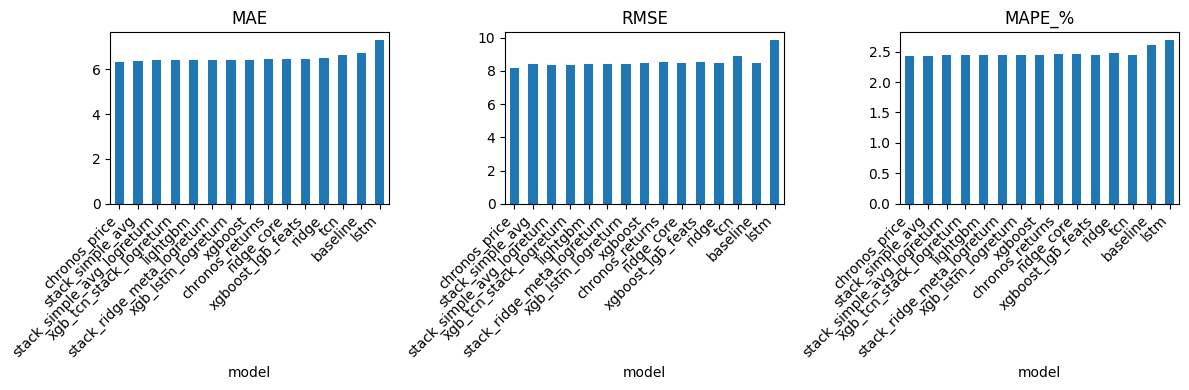

In [8]:
# Overall row only: bar comparison

if overall.empty:
    overall = all_metrics.groupby("model").agg({"MAE": "mean", "RMSE": "mean", "MAPE_%": "mean"}).reset_index()

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["MAE", "RMSE", "MAPE_%"]):
    if col in overall.columns:
        overall.plot(x="model", y=col, kind="bar", ax=ax, legend=False)
        ax.set_title(col)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()